
--- HR_Synth_Data info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8820 entries, 0 to 8819
Data columns (total 36 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       8820 non-null   int64 
 1   Attrition                 8820 non-null   object
 2   BusinessTravel            8820 non-null   object
 3   DailyRate                 8820 non-null   int64 
 4   Department                8820 non-null   object
 5   DistanceFromHome          8820 non-null   object
 6   Education                 8820 non-null   object
 7   EducationField            8820 non-null   object
 8   EmployeeCount             8820 non-null   int64 
 9   EmployeeNumber            8820 non-null   int64 
 10  EnvironmentSatisfaction   8820 non-null   object
 11  Gender                    8820 non-null   object
 12  HourlyRate                8820 non-null   int64 
 13  JobInvolvement            8820 non-null   object
 

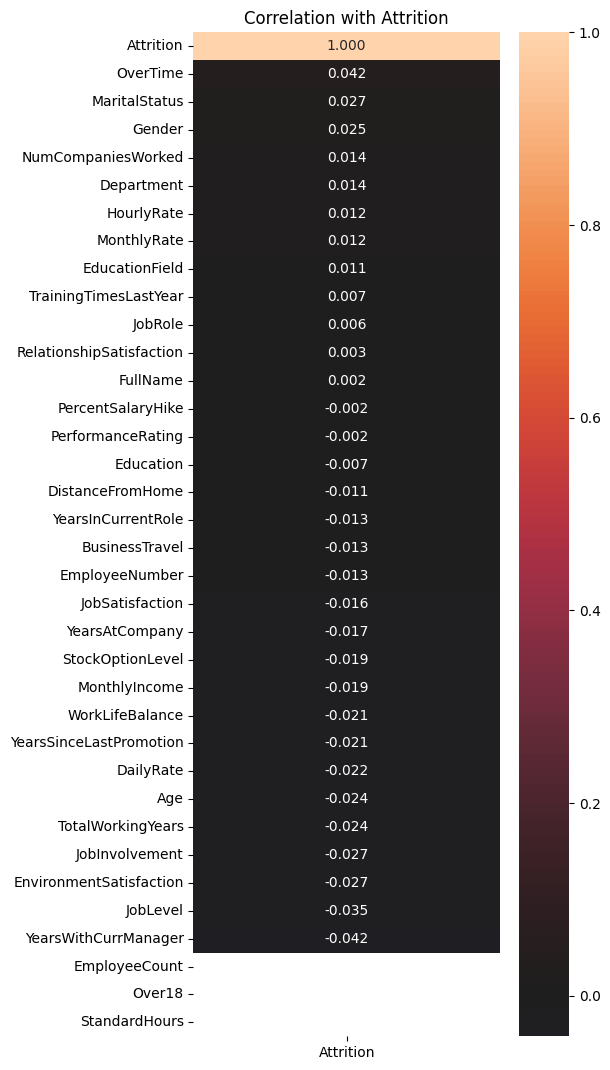

[I 2025-11-26 15:09:01,232] A new study created in memory with name: no-name-5f0679d3-4c4a-42e9-ac98-12849083b121
[I 2025-11-26 15:09:01,385] Trial 0 finished with value: 0.8441043083900227 and parameters: {'n_estimators': 721, 'max_depth': 10, 'learning_rate': 0.04494162900110277, 'subsample': 0.5764817370219558, 'colsample_bytree': 0.9664877055072194, 'min_child_weight': 4.5987337640452814, 'gamma': 0.7546328524257795, 'reg_lambda': 4.838366469707246, 'reg_alpha': 0.9250672467580121}. Best is trial 0 with value: 0.8441043083900227.
[I 2025-11-26 15:09:01,460] Trial 1 finished with value: 0.8441043083900227 and parameters: {'n_estimators': 695, 'max_depth': 9, 'learning_rate': 0.2368304306435764, 'subsample': 0.7434238979299592, 'colsample_bytree': 0.7570611932280473, 'min_child_weight': 4.315580014643282, 'gamma': 2.81474074336166, 'reg_lambda': 0.044302963983280076, 'reg_alpha': 1.1829378807521123}. Best is trial 0 with value: 0.8441043083900227.
[I 2025-11-26 15:09:01,591] Trial 2 


=== Optuna / XGBoost – výsledok ===
Najlepšia accuracy: 0.8441
Najlepšie parametre:
  n_estimators: 721
  max_depth: 10
  learning_rate: 0.04494162900110277
  subsample: 0.5764817370219558
  colsample_bytree: 0.9664877055072194
  min_child_weight: 4.5987337640452814
  gamma: 0.7546328524257795
  reg_lambda: 4.838366469707246
  reg_alpha: 0.9250672467580121
[0]	validation_0-logloss:0.43125
[1]	validation_0-logloss:0.42941
[2]	validation_0-logloss:0.42786
[3]	validation_0-logloss:0.42615
[4]	validation_0-logloss:0.42463
[5]	validation_0-logloss:0.42312
[6]	validation_0-logloss:0.42152
[7]	validation_0-logloss:0.41977
[8]	validation_0-logloss:0.41833
[9]	validation_0-logloss:0.41673
[10]	validation_0-logloss:0.41519
[11]	validation_0-logloss:0.41381
[12]	validation_0-logloss:0.41253
[13]	validation_0-logloss:0.41121
[14]	validation_0-logloss:0.40983
[15]	validation_0-logloss:0.40862
[16]	validation_0-logloss:0.40734
[17]	validation_0-logloss:0.40591
[18]	validation_0-logloss:0.40453
[19]

In [ ]:
# hr_init / inicializácia HR dát
# --------------------------------
# Predpoklady:
#  - v aktuálnom pracovnom adresári je súbor "data.env"
#  - v MS SQL existuje databáza a tabuľka dbo.HR_Synth_Data

import os, optuna, urllib.parse
from pathlib import Path

import pandas as pd
import sqlalchemy as sa

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from xgboost import XGBClassifier, XGBRegressor

DATA_ENV_PATH = Path("data.env")


def load_env_from_file(env_path: Path = DATA_ENV_PATH) -> None:
    if not env_path.exists():
        raise FileNotFoundError(f"Env file not found: {env_path}")

    with env_path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            if "=" not in line:
                continue
            key, value = line.split("=", 1)
            key = key.strip()
            value = value.strip()
            os.environ[key] = value


def make_sql_engine(env_path: Path = DATA_ENV_PATH) -> sa.Engine:
    load_env_from_file(env_path)

    sql_server = os.getenv("SQL_SERVER")
    sql_db     = os.getenv("SQL_DATABASE")
    sql_user   = os.getenv("SQL_USERNAME")
    sql_pwd    = os.getenv("SQL_PASSWORD")
    sql_driver = os.getenv("SQL_DRIVER")
    sql_encrypt = os.getenv("SQL_ENCRYPT")
    sql_trust   = os.getenv("SQL_TRUSTCERT")

    missing = [
        k for k, v in {
            "SQL_SERVER": sql_server,
            "SQL_DATABASE": sql_db,
            "SQL_USERNAME": sql_user,
            "SQL_PASSWORD": sql_pwd,
        }.items() if not v
    ]
    if missing:
        raise RuntimeError(
            f"Missing SQL config keys in {env_path}: {', '.join(missing)}"
        )
    odbc_str = (
        f"DRIVER={{{sql_driver}}};"
        f"SERVER={sql_server};"
        f"DATABASE={sql_db};"
        f"UID={sql_user};"
        f"PWD={sql_pwd};"
        f"Encrypt={sql_encrypt};"
        f"TrustServerCertificate={sql_trust};"
    )

    params = urllib.parse.quote_plus(odbc_str)

    engine = sa.create_engine(
        f"mssql+pyodbc:///?odbc_connect={params}",
        fast_executemany=True,
    )
    return engine


def load_hr_dataframe(env_path: Path = DATA_ENV_PATH) -> pd.DataFrame:
    engine = make_sql_engine(env_path=env_path)
    query = """SELECT 
                [Age],
                [Attrition],
                [BusinessTravel],
                [DailyRate],
                [Department],
                [DistanceFromHome],
                [Education],
                [EducationField],
                [EmployeeCount],
                [EmployeeNumber],
                [EnvironmentSatisfaction],
                [Gender],
                [HourlyRate],
                [JobInvolvement],
                [JobLevel],
                [JobRole],
                [JobSatisfaction],
                [MaritalStatus],
                [MonthlyIncome],
                [MonthlyRate],
                [NumCompaniesWorked],
                [Over18],
                [OverTime],
                [PercentSalaryHike],
                [PerformanceRating],
                [RelationshipSatisfaction],
                [StandardHours],
                [StockOptionLevel],
                [TotalWorkingYears],
                [TrainingTimesLastYear],
                [WorkLifeBalance],
                [YearsAtCompany],
                [YearsInCurrentRole],
                [YearsSinceLastPromotion],
                [YearsWithCurrManager],
                [FullName]               
                FROM dbo.HR_Synth_Data"""
    df = pd.read_sql(query, engine)
    return df

# ==========================
# 2) Preprocessing + LabelEncoder
# ==========================

def encode_categoricals(df: pd.DataFrame):

    df_encoded = df.copy()
    encoders = {}

    cat_cols = df_encoded.select_dtypes(include=["object", "category"]).columns

    for col in cat_cols:
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
        encoders[col] = le

    return df_encoded, encoders


# ==========================
# 3) Heatmap
# ==========================

def plot_attrition_correlation_heatmap(df_encoded: pd.DataFrame, target_col: str = "Attrition"):
    corr = df_encoded.corr(numeric_only=True)

    if target_col not in corr.columns:
        raise ValueError(f"Target column '{target_col}' not found in correlation matrix.")

    target_corr = corr[target_col].sort_values(ascending=False)

    plt.figure(figsize=(6, max(4, len(target_corr) * 0.3)))
    sns.heatmap(
        target_corr.to_frame(),
        annot=True,
        fmt=".3f",
        center=0,
    )
    plt.title(f"Correlation with {target_col}")
    plt.tight_layout()
    plt.show()


# ==========================
# 4) XGBoost + Optuna
# ==========================

def run_xgboost_optuna(
    df_encoded: pd.DataFrame,
    target_col: str = "Attrition",
    test_size: float = 0.2,
    n_trials: int = 100,
    early_stopping_rounds: int = 50,
):
    if target_col not in df_encoded.columns:
        raise ValueError(f"Target column '{target_col}' not found in dataframe.")

    y = df_encoded[target_col]
    feature_drop = [target_col]

    for id_col in ["EmployeeNumber", "EmployeeCount", "FullName", "Over18","StandardHours"]:
        if id_col in df_encoded.columns:
            feature_drop.append(id_col)

    X = df_encoded.drop(columns=feature_drop)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=42,
        stratify=y,
    )

    def objective(trial: optuna.Trial) -> float:
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 100, 800),
            "max_depth": trial.suggest_int("max_depth", 5, 16),
            "learning_rate": trial.suggest_float("learning_rate", 0.001, 0.3, log=True),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 10.0),
            "gamma": trial.suggest_float("gamma", 0.0, 5.0),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
            "random_state": 42,
            "n_jobs": -1,
            "tree_method": "hist",
            "objective": "binary:logistic",
            "eval_metric": "mape",
            "early_stopping_rounds": early_stopping_rounds,
        }

        model = XGBClassifier(**params)

        model.fit(
            X_train,
            y_train,
            eval_set=[(X_test, y_test)],
            verbose=False,
        )

        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        return acc

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

    print("\n=== Optuna / XGBoost – výsledok ===")
    print(f"Najlepšia accuracy: {study.best_value:.4f}")
    print("Najlepšie parametre:")
    for k, v in study.best_params.items():
        print(f"  {k}: {v}")

    best_params = study.best_params.copy()
    best_params.update({
        "random_state": 42,
        "n_jobs": 8,
        "tree_method": "hist",
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "early_stopping_rounds": early_stopping_rounds,
    })

    final_model = XGBClassifier(**best_params)
    final_model.fit(X,y,eval_set=[(X, y)],verbose=True)

    return final_model, study

if __name__ == "__main__":
    df = load_hr_dataframe()
    print("\n--- HR_Synth_Data info ---")
    print(df.info())

    df_encoded, encoders = encode_categoricals(df)

    print("\nUnique values in encoded Attrition:", df_encoded["Attrition"].unique())

    plot_attrition_correlation_heatmap(df_encoded, target_col="Attrition")


    final_model, study = run_xgboost_optuna(
        df_encoded,
        target_col="Attrition",
        test_size=0.2,   # 80:20
        n_trials=100
    )

    print("\nModel je natrénovaný – môžeš ho použiť na scoring ďalších dát.")
